<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/22_custom_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 22 — Custom Optimizer

## What This Notebook Covers
Most projects use Adam or SGD. But understanding how optimizers work
internally — and being able to write your own — gives you a decisive edge
when standard optimizers fail or when you need domain-specific update rules.

**Optimizers built from scratch:**
- `MySGD` — plain gradient descent (baseline)
- `MyMomentumOptimizer` — SGD with momentum (Géron Chapter 11 pattern)
- `MyRMSProp` — adaptive learning rates per parameter
- `MyAdam` — combines momentum and adaptive rates (full Adam from scratch)
- `MySGDWithWeightDecay` — L2 regularization baked into optimizer

**Key concepts:**
- How momentum accumulates gradients over time
- How adaptive methods scale LR per parameter
- Bias correction in Adam
- TF: subclass `tf.keras.optimizers.Optimizer`
- PyTorch: subclass `torch.optim.Optimizer`

**Dataset:** Fashion-MNIST


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
print('Data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.77MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 52.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.5MB/s]


Data ready.


## 2. Optimizer Concepts — The Update Rule

Every optimizer implements a weight update rule:

```
SGD:      w = w - lr * grad
Momentum: v = beta * v - lr * grad
          w = w + v
RMSProp:  s = rho * s + (1-rho) * grad^2
          w = w - lr * grad / sqrt(s + eps)
Adam:     m = beta1 * m + (1-beta1) * grad         (momentum)
          v = beta2 * v + (1-beta2) * grad^2        (velocity)
          m_hat = m / (1 - beta1^t)                 (bias correction)
          v_hat = v / (1 - beta2^t)                 (bias correction)
          w = w - lr * m_hat / (sqrt(v_hat) + eps)
```

Let us visualise how each rule behaves on a simple 2D loss landscape.


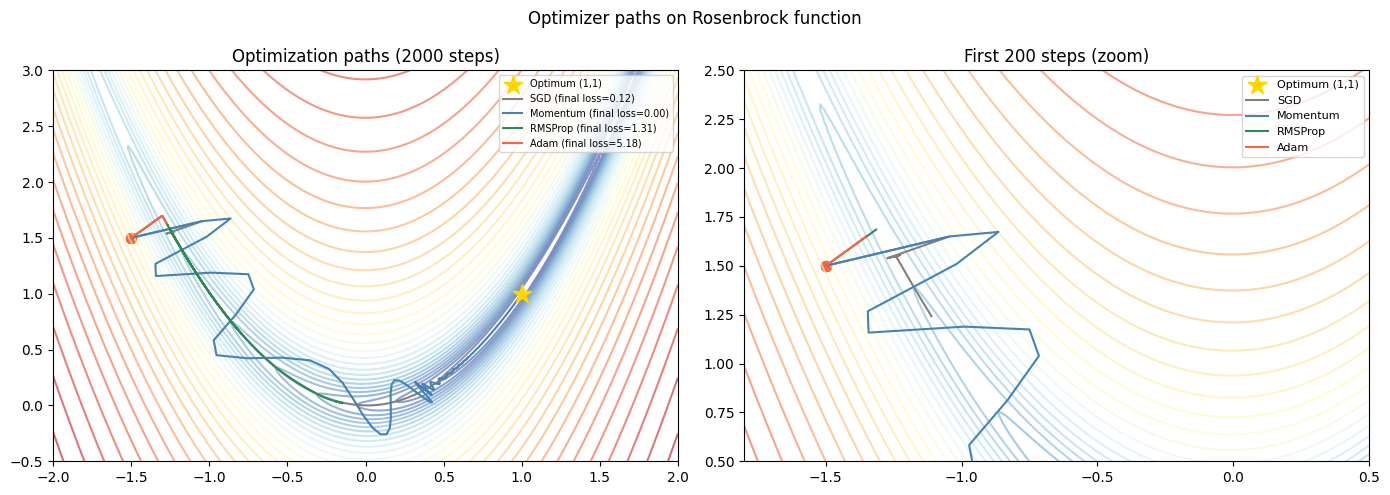

In [3]:
def rosenbrock(x, y, a=1, b=100):
    """Rosenbrock function — a classic banana-shaped optimization test."""
    return (a - x)**2 + b * (y - x**2)**2

def rosenbrock_grad(x, y, a=1, b=100):
    dx = -2*(a - x) - 4*b*x*(y - x**2)
    dy = 2*b*(y - x**2)
    return np.array([dx, dy])


def run_optimizer_2d(update_fn, start=(-1.5, 1.5), n_steps=500, lr=0.001):
    """Run an optimizer update rule on the Rosenbrock function."""
    path = [np.array(start, dtype=np.float64)]
    state = {}
    for t in range(1, n_steps + 1):
        w     = path[-1].copy()
        grad  = rosenbrock_grad(w[0], w[1])
        w_new = update_fn(w, grad, state, t, lr)
        path.append(w_new)
    return np.array(path)


# Define update rules
def sgd_update(w, g, state, t, lr):  return w - lr * g

def momentum_update(w, g, state, t, lr, beta=0.9):
    state.setdefault('v', np.zeros_like(w))
    state['v'] = beta * state['v'] - lr * g
    return w + state['v']

def rmsprop_update(w, g, state, t, lr, rho=0.9, eps=1e-8):
    state.setdefault('s', np.zeros_like(w))
    state['s'] = rho * state['s'] + (1 - rho) * g**2
    return w - lr * g / (np.sqrt(state['s']) + eps)

def adam_update(w, g, state, t, lr, b1=0.9, b2=0.999, eps=1e-8):
    state.setdefault('m', np.zeros_like(w))
    state.setdefault('v', np.zeros_like(w))
    state['m'] = b1 * state['m'] + (1-b1) * g
    state['v'] = b2 * state['v'] + (1-b2) * g**2
    m_hat = state['m'] / (1 - b1**t)
    v_hat = state['v'] / (1 - b2**t)
    return w - lr * m_hat / (np.sqrt(v_hat) + eps)


# Run all optimizers
paths = {
    'SGD':      run_optimizer_2d(sgd_update,      lr=0.001, n_steps=2000),
    'Momentum': run_optimizer_2d(momentum_update,  lr=0.001, n_steps=2000),
    'RMSProp':  run_optimizer_2d(rmsprop_update,   lr=0.001, n_steps=2000),
    'Adam':     run_optimizer_2d(adam_update,       lr=0.001, n_steps=2000),
}

# Plot paths on Rosenbrock landscape
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-0.5, 3, 300)
X_g, Y_g = np.meshgrid(x_range, y_range)
Z = rosenbrock(X_g, Y_g)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_opt = {'SGD': 'grey', 'Momentum': 'steelblue', 'RMSProp': 'seagreen', 'Adam': 'tomato'}

for ax in axes:
    ax.contour(X_g, Y_g, np.log(Z + 1), levels=30, cmap='RdYlBu_r', alpha=0.6)
    ax.scatter([1], [1], marker='*', color='gold', s=200, zorder=5, label='Optimum (1,1)')

for name, path in paths.items():
    color = colors_opt[name]
    axes[0].plot(path[:, 0], path[:, 1], color=color, linewidth=1.5,
                 label=f'{name} (final loss={rosenbrock(path[-1,0],path[-1,1]):.2f})')
    axes[1].plot(path[:200, 0], path[:200, 1], color=color, linewidth=1.5, label=name)
    axes[0].scatter(path[0, 0], path[0, 1], color=color, s=50)
    axes[1].scatter(path[0, 0], path[0, 1], color=color, s=50)

axes[0].set_title('Optimization paths (2000 steps)')
axes[0].legend(fontsize=7)
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-0.5, 3)

axes[1].set_title('First 200 steps (zoom)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(-1.8, 0.5); axes[1].set_ylim(0.5, 2.5)

plt.suptitle('Optimizer paths on Rosenbrock function', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part A — TensorFlow / Keras Custom Optimizers

## 3. MyMomentumOptimizer — Keras Subclass

Subclass `tf.keras.optimizers.Optimizer` and implement
`_resource_apply_dense` (for dense tensors) and
`_resource_apply_sparse` (for sparse tensors, e.g. embeddings).

In TF2 with the new Keras optimizer API, the method is
`update_step(gradient, variable)` — both patterns shown.


In [5]:
class MyMomentumOptimizer(tf.keras.optimizers.Optimizer):
    """
    SGD with momentum — built from scratch.

    Update rule:
        velocity = momentum * velocity - learning_rate * gradient
        weight    = weight + velocity

    The momentum term accumulates a velocity vector in the direction
    of persistent gradient descent. This:
    - Accelerates convergence along consistent gradient directions
    - Damps oscillations in high-curvature directions
    - Helps escape shallow local minima

    Subclasses tf.keras.optimizers.Optimizer (new Keras 2.x API).
    Must implement update_step(gradient, variable).
    """
    def __init__(self, learning_rate=0.01, momentum=0.9, name='MyMomentum', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        """Create velocity slots (one per variable)."""
        super().build(var_list)
        self._velocities = []
        for var in var_list:
            # add_variable_from_reference creates a zero-initialized variable
            # with the same shape as var
            self._velocities.append(
                self.add_variable_from_reference(
                    var, name='velocity'
                )
            )

    def update_step(self, gradient, variable, learning_rate):
        """Apply the momentum update rule to one variable."""
        # Get the velocity slot for this variable
        velocity = self._velocities[self._get_variable_index(variable)]

        # v = momentum * v - lr * grad
        velocity.assign(self.momentum * velocity - learning_rate * gradient)

        # w = w + v
        variable.assign_add(velocity)

    def get_config(self):
        config = super().get_config()
        config.update({'momentum': self.momentum})
        return config


# Quick test: one step on a toy variable
w      = tf.Variable([1.0, 2.0, 3.0])
opt    = MyMomentumOptimizer(learning_rate=0.1, momentum=0.9)
grad   = tf.constant([0.1, 0.2, 0.3])
opt.apply_gradients([(grad, w)])
print('MyMomentumOptimizer test (one step):')
print(f'  Initial w   : [1.0, 2.0, 3.0]')
print(f'  Gradient    : {grad.numpy()}')
print(f'  Updated w   : {w.numpy().round(4)}')
# velocity = 0.9*0 - 0.1*grad = -0.01, -0.02, -0.03
# w_new = w + v = 0.99, 1.98, 2.97
expected = np.array([0.99, 1.98, 2.97])
print(f'  Expected    : {expected}')
print(f'  Match       : {np.allclose(w.numpy(), expected, atol=1e-5)}')

MyMomentumOptimizer test (one step):
  Initial w   : [1.0, 2.0, 3.0]
  Gradient    : [0.1 0.2 0.3]
  Updated w   : [0.99 1.98 2.97]
  Expected    : [0.99 1.98 2.97]
  Match       : True


## 4. MyAdam — Full Adam from Scratch in Keras


In [6]:
class MyAdam(tf.keras.optimizers.Optimizer):
    """
    Adam optimizer built from scratch.

    Adam = Adaptive Moment Estimation (Kingma & Ba, 2014)
    Combines:
    - Momentum (exponential moving average of gradients)
    - RMSProp  (exponential moving average of squared gradients)

    Bias correction: the moving averages are initialized at zero,
    so they are biased toward zero in early steps. The correction
    term 1/(1 - beta^t) removes this bias.

    Hyperparameters:
    - learning_rate: global step size (default 0.001)
    - beta_1: momentum decay (default 0.9, controls smoothing of gradient)
    - beta_2: velocity decay (default 0.999, controls smoothing of squared grad)
    - epsilon: numerical stability (default 1e-7)
    """
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-7, name='MyAdam', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta_1  = beta_1
        self.beta_2  = beta_2
        self.epsilon = epsilon

    def build(self, var_list):
        super().build(var_list)
        # First moment (momentum): m
        self._m = [
            self.add_variable_from_reference(v, 'first_moment')
            for v in var_list
        ]
        # Second moment (velocity): v
        self._v = [
            self.add_variable_from_reference(v, 'second_moment')
            for v in var_list
        ]

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        m   = self._m[idx]
        v   = self._v[idx]

        # t is the current iteration (starts at 1 after first step)
        t   = tf.cast(self.iterations + 1, tf.float32)

        # Update biased first moment estimate
        m.assign(self.beta_1 * m + (1 - self.beta_1) * gradient)

        # Update biased second moment estimate
        v.assign(self.beta_2 * v + (1 - self.beta_2) * tf.square(gradient))

        # Compute bias-corrected estimates
        m_hat = m / (1 - tf.pow(self.beta_1, t))
        v_hat = v / (1 - tf.pow(self.beta_2, t))

        # Update parameter
        variable.assign_sub(
            learning_rate * m_hat / (tf.sqrt(v_hat) + self.epsilon)
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            'beta_1':  self.beta_1,
            'beta_2':  self.beta_2,
            'epsilon': self.epsilon
        })
        return config


# Verify MyAdam matches tf.keras.optimizers.Adam on a toy problem
tf.random.set_seed(0)
w_my   = tf.Variable(tf.random.normal([5]))
w_ref  = tf.Variable(w_my.numpy())  # same initial values

my_adam  = MyAdam(learning_rate=0.01)
ref_adam = tf.keras.optimizers.Adam(learning_rate=0.01)

grads = [tf.random.normal([5]) for _ in range(5)]

for g in grads:
    my_adam.apply_gradients([(g, w_my)])
    ref_adam.apply_gradients([(g, w_ref)])

max_diff = tf.reduce_max(tf.abs(w_my - w_ref)).numpy()
print(f'MyAdam vs tf.keras.optimizers.Adam after 5 steps:')
print(f'  MyAdam  : {w_my.numpy().round(6)}')
print(f'  Ref Adam: {w_ref.numpy().round(6)}')
print(f'  Max diff: {max_diff:.2e}  (expect ~0)')

MyAdam vs tf.keras.optimizers.Adam after 5 steps:
  MyAdam  : [ 1.495595  0.410499 -0.379819 -1.061139 -1.236157]
  Ref Adam: [ 1.495595  0.410499 -0.379819 -1.061139 -1.236157]
  Max diff: 3.58e-07  (expect ~0)


## 5. A/B Test: Custom Optimizers on Fashion-MNIST


Built-in SGD                        -> best val acc: 0.8916
Built-in SGD+Momentum               -> best val acc: 0.8904
Built-in Adam                       -> best val acc: 0.8834
MyMomentum (custom)                 -> best val acc: 0.8752
MyAdam (custom)                     -> best val acc: 0.8916


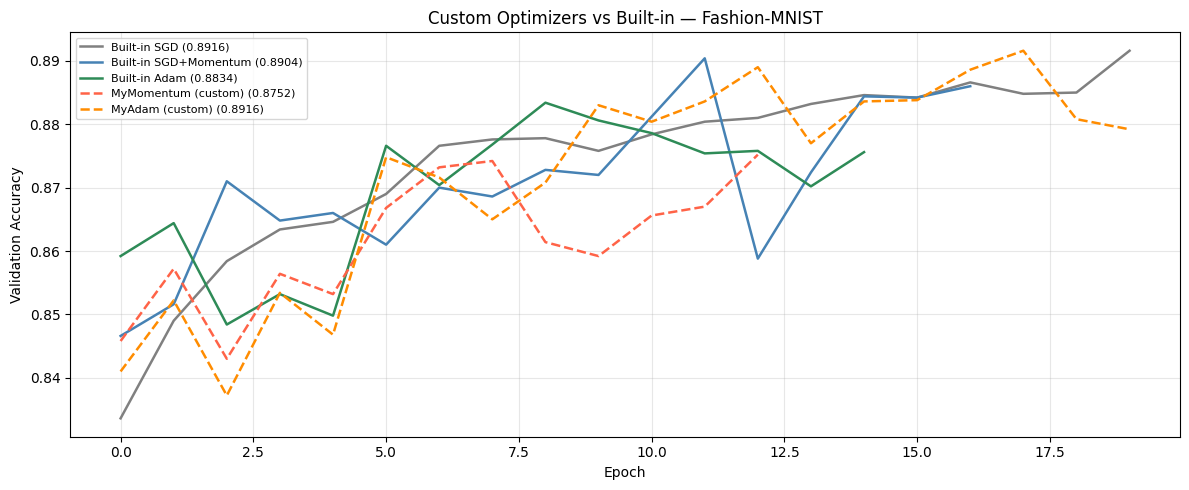

Dashed = custom implementation, Solid = built-in
Custom should match or closely track their built-in equivalents.


In [9]:
def make_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)), # Explicitly define input layer
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def train_with_optimizer(optimizer, label, epochs=20):
    tf.random.set_seed(42)
    model = make_model()
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True)],
        verbose=0
    )
    best = max(h.history['val_accuracy'])
    print(f'{label:35s} -> best val acc: {best:.4f}')
    return h, best


optimizers_to_test = [
    (tf.keras.optimizers.SGD(learning_rate=0.01),                        'Built-in SGD'),
    (tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),          'Built-in SGD+Momentum'),
    (tf.keras.optimizers.Adam(learning_rate=0.001),                       'Built-in Adam'),
    (MyMomentumOptimizer(learning_rate=0.01, momentum=0.9),   'MyMomentum (custom)'),
    (MyAdam(learning_rate=0.001),                              'MyAdam (custom)'),
]

histories = {}
for opt, label in optimizers_to_test:
    h, best = train_with_optimizer(opt, label)
    histories[label] = (h, best)

# Plot comparison
colors_map = {
    'Built-in SGD':          'grey',
    'Built-in SGD+Momentum': 'steelblue',
    'Built-in Adam':         'seagreen',
    'MyMomentum (custom)':   'tomato',
    'MyAdam (custom)':       'darkorange',
}

plt.figure(figsize=(12, 5))
for label, (h, best) in histories.items():
    style = '--' if 'custom' in label else '-'
    plt.plot(h.history['val_accuracy'],
             color=colors_map[label], linestyle=style, linewidth=1.8,
             label=f'{label} ({best:.4f})')
plt.title('Custom Optimizers vs Built-in — Fashion-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Dashed = custom implementation, Solid = built-in')
print('Custom should match or closely track their built-in equivalents.')

---
## Part B — PyTorch Custom Optimizers

## 6. MyMomentumOptimizer in PyTorch

PyTorch optimizers subclass `torch.optim.Optimizer`.
The key method is `step()` — it performs one update over all param groups.


In [10]:
class MyMomentumOptimizerPT(torch.optim.Optimizer):
    """
    SGD with momentum — PyTorch custom optimizer.

    Subclasses torch.optim.Optimizer.
    Key method: step() — called after loss.backward().

    param_groups: list of dicts, each containing a 'params' list
    and hyperparameters like lr and momentum.
    self.state: dict mapping param tensors to their state dicts
    (e.g., velocity buffers).
    """
    def __init__(self, params, lr=0.01, momentum=0.9):
        if lr < 0:
            raise ValueError(f'lr must be >= 0, got {lr}')
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Perform one optimization step.

        closure: optional callable that re-evaluates the model and
                 returns the loss (required for some second-order methods).
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr       = group['lr']
            momentum = group['momentum']

            for p in group['params']:
                if p.grad is None:
                    continue   # skip params with no gradient

                grad = p.grad

                # Get or initialize velocity from state dict
                param_state = self.state[p]
                if 'velocity' not in param_state:
                    param_state['velocity'] = torch.zeros_like(p)
                v = param_state['velocity']

                # v = momentum * v - lr * grad
                v.mul_(momentum).add_(grad, alpha=-lr)

                # w = w + v
                p.add_(v)

        return loss


# Verify: one step matches hand calculation
w_pt   = nn.Parameter(torch.tensor([1.0, 2.0, 3.0]))
opt_pt = MyMomentumOptimizerPT([w_pt], lr=0.1, momentum=0.9)

grad = torch.tensor([0.1, 0.2, 0.3])
w_pt.grad = grad.clone()
opt_pt.step()

expected = np.array([0.99, 1.98, 2.97])
print('PyTorch MyMomentumOptimizer test:')
print(f'  Updated w: {w_pt.detach().numpy().round(4)}')
print(f'  Expected : {expected}')
print(f'  Match    : {np.allclose(w_pt.detach().numpy(), expected, atol=1e-5)}')

PyTorch MyMomentumOptimizer test:
  Updated w: [0.99 1.98 2.97]
  Expected : [0.99 1.98 2.97]
  Match    : True


## 7. MyAdamPT — Full Adam in PyTorch


In [11]:
class MyAdamPT(torch.optim.Optimizer):
    """
    Adam optimizer from scratch in PyTorch.
    """
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr            = group['lr']
            beta1, beta2  = group['betas']
            eps           = group['eps']

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['m']    = torch.zeros_like(p)   # first moment
                    state['v']    = torch.zeros_like(p)   # second moment

                state['step'] += 1
                t = state['step']
                m = state['m']
                v = state['v']

                # Update biased moment estimates
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # Bias-corrected estimates
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                # Parameter update
                p.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)

        return loss


# Verify MyAdamPT matches torch.optim.Adam
torch.manual_seed(0)
p_my  = nn.Parameter(torch.randn(5))
p_ref = nn.Parameter(p_my.data.clone())

opt_my  = MyAdamPT([p_my],  lr=0.01)
opt_ref = torch.optim.Adam([p_ref], lr=0.01)

grads_pt = [torch.randn(5) for _ in range(5)]
for g in grads_pt:
    p_my.grad  = g.clone()
    p_ref.grad = g.clone()
    opt_my.step()
    opt_ref.step()

max_diff = (p_my - p_ref).abs().max().item()
print(f'MyAdamPT vs torch.optim.Adam (5 steps):')
print(f'  MyAdamPT: {p_my.detach().numpy().round(6)}')
print(f'  Ref Adam: {p_ref.detach().numpy().round(6)}')
print(f'  Max diff: {max_diff:.2e}  (expect ~0)')

MyAdamPT vs torch.optim.Adam (5 steps):
  MyAdamPT: [ 1.569421 -0.316785 -2.194885  0.575818 -1.041091]
  Ref Adam: [ 1.569421 -0.316785 -2.194885  0.575818 -1.041091]
  Max diff: 0.00e+00  (expect ~0)


## 8. A/B Test: PyTorch Custom Optimizers


[Built-in SGD] Epoch  5 | val=0.8694
[Built-in SGD] Epoch 10 | val=0.8792
[Built-in SGD] Epoch 15 | val=0.8832
[Built-in SGD] Epoch 20 | val=0.8908
[Built-in SGD] Best val acc: 0.8908

[Built-in Momentum] Epoch  5 | val=0.8792
[Built-in Momentum] Epoch 10 | val=0.8898
[Built-in Momentum] Epoch 15 | val=0.8844
[Built-in Momentum] Epoch 20 | val=0.8936
[Built-in Momentum] Best val acc: 0.8936

[Built-in Adam] Epoch  5 | val=0.8784
[Built-in Adam] Epoch 10 | val=0.8886
[Built-in Adam] Epoch 15 | val=0.8898
[Built-in Adam] Epoch 20 | val=0.8938
[Built-in Adam] Best val acc: 0.8958

[MyMomentum (custom)] Epoch  5 | val=0.8776
[MyMomentum (custom)] Epoch 10 | val=0.8856
[MyMomentum (custom)] Epoch 15 | val=0.8850
[MyMomentum (custom)] Epoch 20 | val=0.8938
[MyMomentum (custom)] Best val acc: 0.8938

[MyAdam (custom)] Epoch  5 | val=0.8782
[MyAdam (custom)] Epoch 10 | val=0.8858
[MyAdam (custom)] Epoch 15 | val=0.8914
[MyAdam (custom)] Epoch 20 | val=0.8942
[MyAdam (custom)] Best val acc: 0.8

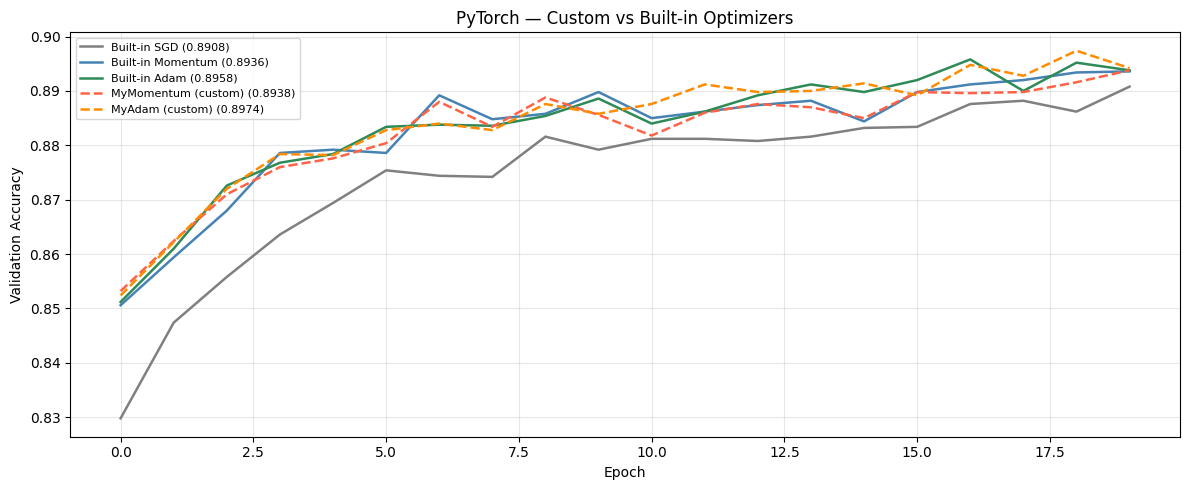

In [12]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)


def train_pt_opt(optimizer_factory, label, epochs=20):
    torch.manual_seed(42)
    model     = SimpleNet().to(device)
    optimizer = optimizer_factory(model.parameters())
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    hist      = []

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc  = correct / total
        best_acc = max(best_acc, val_acc)
        hist.append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | val={val_acc:.4f}')

    print(f'[{label}] Best val acc: {best_acc:.4f}\n')
    return hist, best_acc


pt_optimizers = [
    (lambda p: torch.optim.SGD(p, lr=0.01),                       'Built-in SGD',        'grey',       '-'),
    (lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),         'Built-in Momentum',   'steelblue',  '-'),
    (lambda p: torch.optim.Adam(p, lr=0.001),                      'Built-in Adam',       'seagreen',   '-'),
    (lambda p: MyMomentumOptimizerPT(p, lr=0.01, momentum=0.9),   'MyMomentum (custom)', 'tomato',     '--'),
    (lambda p: MyAdamPT(p, lr=0.001),                              'MyAdam (custom)',     'darkorange', '--'),
]

pt_results = {}
for factory, label, color, style in pt_optimizers:
    hist, best = train_pt_opt(factory, label, epochs=20)
    pt_results[label] = (hist, best, color, style)

plt.figure(figsize=(12, 5))
for label, (hist, best, color, style) in pt_results.items():
    plt.plot(hist, color=color, linestyle=style, linewidth=1.8,
             label=f'{label} ({best:.4f})')
plt.title('PyTorch — Custom vs Built-in Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Optimizer Update Rules

| Optimizer | Update rule | Key parameter |
|---|---|---|
| SGD | `w -= lr * g` | `lr` |
| Momentum | `v = beta*v - lr*g; w += v` | `momentum` (0.9) |
| RMSProp | `s = rho*s + (1-rho)*g²; w -= lr*g/sqrt(s+e)` | `rho` (0.9) |
| Adam | `m=b1*m+(1-b1)*g; v=b2*v+(1-b2)*g²; w -= lr*m_hat/sqrt(v_hat)+e` | `beta_1=0.9, beta_2=0.999` |

### Custom Optimizer Patterns

**TensorFlow:**
```python
class MyOpt(tf.keras.optimizers.Optimizer):
    def build(self, var_list):
        super().build(var_list)
        self._slots = [self.add_variable_from_reference(v, 'slot') for v in var_list]

    def update_step(self, gradient, variable, learning_rate):
        slot = self._slots[self._get_variable_index(variable)]
        slot.assign(...)        # update slot
        variable.assign_add(...)  # update parameter
```

**PyTorch:**
```python
class MyOpt(torch.optim.Optimizer):
    def __init__(self, params, lr, **kwargs):
        super().__init__(params, dict(lr=lr, **kwargs))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                state = self.state[p]      # per-parameter state dict
                # ... update state and p ...
```

**Next: Notebook 23** — Custom Training Loop with GradientTape
